# Notebook 04 — Escalamiento y PCA
**Proyecto Integrador | Minería de Datos I**

## Objetivo
Aplicar escalamiento y reducción de dimensionalidad mediante PCA sobre el dataset limpio, documentando las variables utilizadas, el escalamiento aplicado, la varianza explicada y la interpretación de las componentes obtenidas.

## Etapa
Esta es la etapa 4 de 5. Se trabaja sobre `data/processed/streaming_users_clean.csv`.

In [1]:
# --- 1. IMPORTACIONES Y CARGA DEL DATASET ESTABILIZADO ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración estética para los gráficos del modelo
sns.set_theme(style="white")

# Carga del archivo generado al final del EDA (Asegúrate de poner tu ruta correcta)
df = pd.read_csv('../data/processed/streaming_users_clean.csv')

print("--- VERIFICACIÓN DE INTEGRIDAD DE ENTRADA ---")
print(f"Dimensiones del DataFrame: {df.shape[0]} filas | {df.shape[1]} columnas")
print(f"Cantidad total de valores nulos en la base: {df.isnull().sum().sum()}")

--- VERIFICACIÓN DE INTEGRIDAD DE ENTRADA ---
Dimensiones del DataFrame: 8000 filas | 8 columnas
Cantidad total de valores nulos en la base: 0


### Paso 2: Codificación de variables categóricas
Para aplicar PCA las variables deben ser numéricas. Las columnas `subscription_plan`, `country` y `favorite_genre` son categóricas, por lo que se aplica One-Hot Encoding con `drop_first=True` para evitar redundancia estadística. Las columnas `user_id` y `last_login_date` se excluyen por no aportar información de comportamiento al análisis.

In [2]:
# --- 2. INGENIERÍA DE CARACTERÍSTICAS: CODIFICACIÓN CATEGÓRICA ---

# Seleccionamos las columnas cualitativas a transformar
columnas_categoricas = ['subscription_plan', 'country', 'favorite_genre']

# Aplicamos One-Hot Encoding optimizado (drop_first=True evita redundancia estadística)
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

# Pasamos a numéricas también las fechas si es necesario, o eliminamos IDs/Fechas 
# para que el PCA trabaje solo con variables de comportamiento o demográficas.
# Nota: Guardamos los IDs en una variable aparte por seguridad.
user_ids = df_encoded['user_id']
X = df_encoded.drop(columns=['user_id', 'last_login_date'])

print("--- ESTRUCTURA POST-ENCODING ---")
print(f"Nuevas dimensiones para el espacio de características (X): {X.shape[0]} filas | {X.shape[1]} variables")

--- ESTRUCTURA POST-ENCODING ---
Nuevas dimensiones para el espacio de características (X): 8000 filas | 18 variables


### Paso 3: Escalamiento de variables
PCA es sensible a las magnitudes de las variables. Por ejemplo, `monthly_watch_time_mins` tiene valores en el rango de 0 a 4000, mientras que `age` va de 18 a 80. Sin escalar, las variables con mayor magnitud dominarían los componentes. Se aplica `StandardScaler` para que todas las variables tengan media 0 y desvío estándar 1, garantizando que cada variable contribuya equitativamente al análisis.

In [3]:
# --- 3. ESTANDARIZACIÓN DE VARIABLES (ESCALADO MATRICIAL) ---

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lo convertimos temporalmente a DataFrame para verificar que las medias queden en 0 y desvíos en 1
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("--- AUDITORÍA DEL ESCALADO ---")
print(f"Media promedio de las variables scaleadas (esperado ~0): {np.allclose(X_scaled_df.mean(), 0)}")
print(f"Desvío estándar promedio (esperado ~1): {np.allclose(X_scaled_df.std(ddof=0), 1)}")

--- AUDITORÍA DEL ESCALADO ---
Media promedio de las variables scaleadas (esperado ~0): True
Desvío estándar promedio (esperado ~1): True


### Paso 4: Aplicación de PCA
Se aplica PCA sobre las 18 variables escaladas calculando todos los componentes posibles. El objetivo es identificar las direcciones de mayor variabilidad en los datos y reducir la dimensionalidad conservando la mayor cantidad de información posible.

In [4]:
# Paso 4: Aplicación de PCA
pca = PCA()
pca.fit(X_scaled)

print(f"Número de componentes calculados: {pca.n_components_}")
print(f"\nVarianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")

Número de componentes calculados: 18

Varianza explicada por componente:
  PC1: 8.06%
  PC2: 6.69%
  PC3: 6.63%
  PC4: 6.61%
  PC5: 6.56%
  PC6: 6.52%
  PC7: 6.46%
  PC8: 6.44%
  PC9: 6.36%
  PC10: 6.32%
  PC11: 6.29%
  PC12: 6.03%
  PC13: 5.75%
  PC14: 5.53%
  PC15: 5.47%
  PC16: 2.48%
  PC17: 0.90%
  PC18: 0.88%


### Paso 5: Varianza explicada y Scree Plot
Para determinar cuántos componentes son suficientes, se analiza la varianza explicada acumulada. El criterio utilizado es retener los componentes necesarios para superar el 80% de varianza explicada, equilibrando reducción de dimensionalidad y preservación de información.

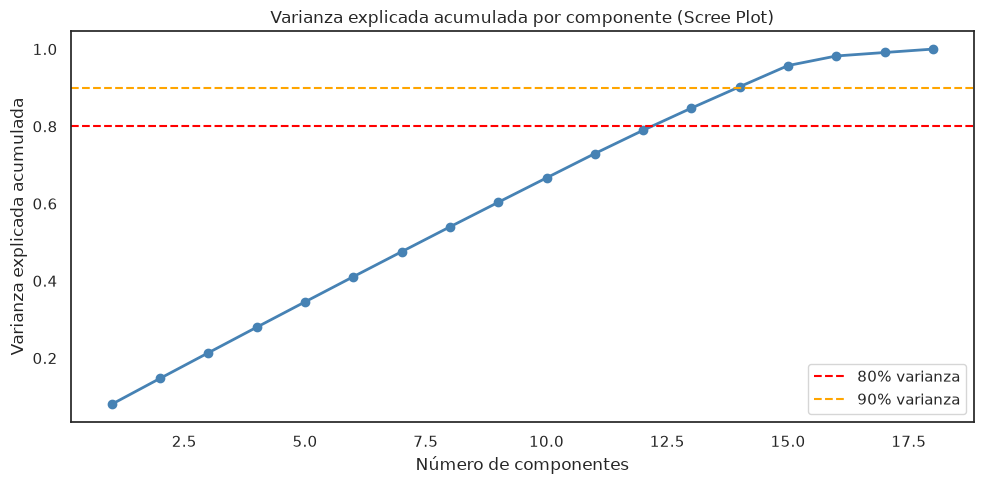

Componentes para explicar el 80% de la varianza: 13
Componentes para explicar el 90% de la varianza: 14


In [5]:
# Scree plot - Varianza explicada acumulada
import numpy as np
import matplotlib.pyplot as plt

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=0.80, color='red', linestyle='--', label='80% varianza')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
plt.title('Varianza explicada acumulada por componente (Scree Plot)')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.tight_layout()
plt.show()

# Cuántos componentes se necesitan para cada umbral
for umbral in [0.80, 0.90]:
    n = next(i+1 for i, v in enumerate(varianza_acumulada) if v >= umbral)
    print(f"Componentes para explicar el {int(umbral*100)}% de la varianza: {n}")

### Interpretación del Scree Plot
El gráfico muestra la varianza acumulada a medida que se agregan componentes. El punto donde la curva supera el 80% indica el número mínimo de componentes necesarios para representar adecuadamente los datos sin perder demasiada información. A partir de ese punto, cada componente adicional aporta cada vez menos información nueva.

### Paso 6: Análisis de Cargas (Loadings) por Componente
Para interpretar qué representan PC1 y PC2, se extraen las cargas de cada variable en cada componente. Una carga alta en valor absoluto indica que esa variable tiene mucha influencia en ese componente. Se visualizan las 5 variables con mayor peso en PC1 y PC2 para identificar qué dimensión del comportamiento del usuario captura cada componente principal.

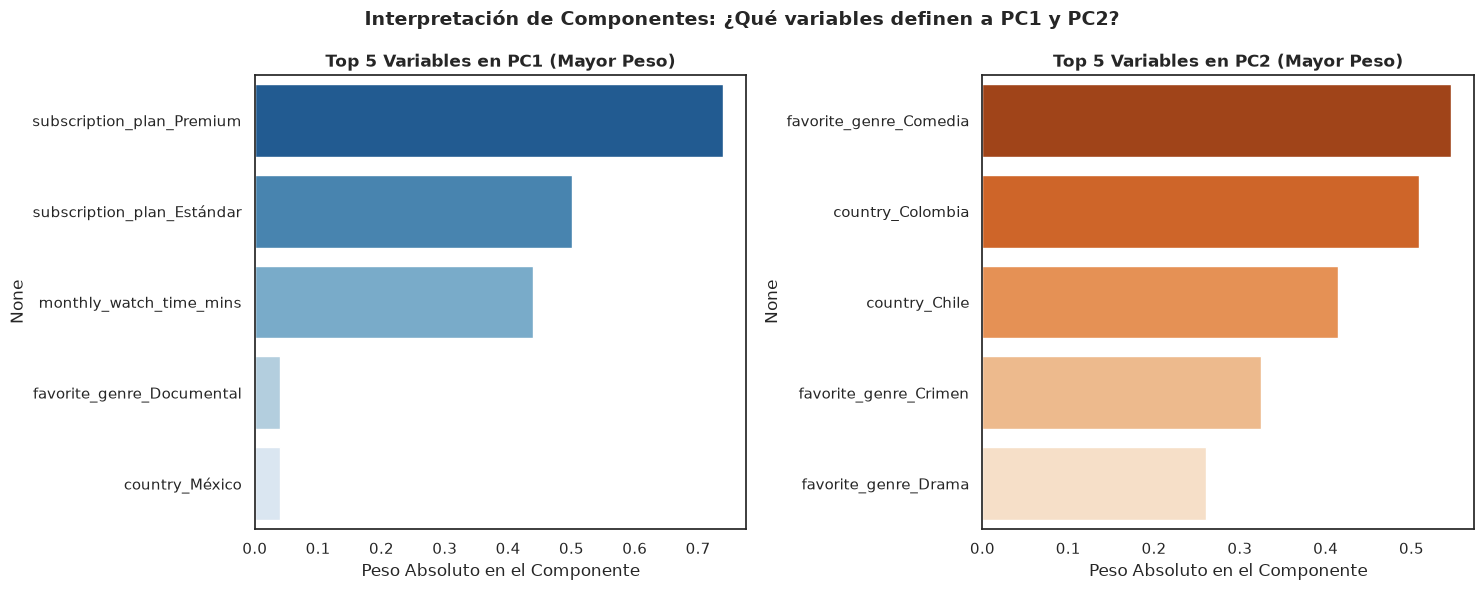

In [6]:
# --- ANÁLISIS DE CARGA DE VARIABLES (LOADINGS) EN LOS COMPONENTES ---

# 1. Extraemos las cargas (loadings) del PCA
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(X.columns))], 
    index=X.columns
)

# 2. Configuramos la figura para comparar PC1 y PC2
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)

# --- COMPONENTE PRINCIPAL 1 ---
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
# Corrección de Seaborn v0.14: Asignamos y a hue para eliminar el FutureWarning
sns.barplot(
    x=top_pc1.values, 
    y=top_pc1.index, 
    ax=axes[0], 
    hue=top_pc1.index, 
    palette='Blues_r', 
    legend=False
)
axes[0].set_title('Top 5 Variables en PC1 (Mayor Peso)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Peso Absoluto en el Componente')

# --- COMPONENTE PRINCIPAL 2 ---
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(5)
# Corrección de Seaborn v0.14: Asignamos y a hue para eliminar el FutureWarning
sns.barplot(
    x=top_pc2.values, 
    y=top_pc2.index, 
    ax=axes[1], 
    hue=top_pc2.index, 
    palette='Oranges_r', 
    legend=False
)
axes[1].set_title('Top 5 Variables en PC2 (Mayor Peso)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Peso Absoluto en el Componente')

plt.suptitle('Interpretación de Componentes: ¿Qué variables definen a PC1 y PC2?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de los Componentes Principales (Loadings)

**PC1 — Dimensión de plan y consumo:**
Las variables con mayor peso en PC1 son `subscription_plan_Premium`, `subscription_plan_Estándar` y `monthly_watch_time_mins`. Esto indica que el primer componente captura principalmente la dimensión comercial del usuario: el tipo de plan contratado y el nivel de consumo mensual. Los usuarios se diferencian más entre sí por el plan que eligieron y cuánto consumen que por cualquier otra variable.

**PC2 — Dimensión de preferencias y origen geográfico:**
Las variables con mayor peso en PC2 son `favorite_genre_Comedia`, `country_Colombia`, `country_Chile` y `favorite_genre_Crimen`. El segundo componente captura preferencias de contenido y origen geográfico, sugiriendo que hay cierta asociación entre el país del usuario y los géneros que consume.

**Limitación del PCA:**
Se necesitan 13 componentes para explicar el 80% de la varianza y 14 para el 90%. Esto confirma que las variables del dataset no están fuertemente correlacionadas entre sí, lo que limita la capacidad de reducción de dimensionalidad del PCA. Este resultado es consistente con el heatmap de correlación del EDA donde las correlaciones entre variables numéricas fueron prácticamente nulas.